# Data Visualization (non‑map) — Complementary to Mapping Notebook

This notebook focuses on non‑geospatial insights (distributions, rankings, correlations) to complement the maps in `us_high_income_jobs_mapping.ipynb`.

Naming policy:
- Plots in this notebook never reuse image filenames from the mapping notebook.
- If a filename overlaps, it will be automatically renamed with a `_Viz` suffix to keep images unique.


# High-Paying Jobs in the US — Visual Analysis

This notebook explores high-paying jobs ($100K+) across the US with a focus on:
- Top occupations by average income
- Income by education level
- Gender distribution across occupations and states
- Salary distributions for top occupations
- Relationship between age and income
- Correlations among numeric features

Scope: non-map visuals only. Choropleth maps are in `us_high_income_jobs_mapping.ipynb`.
Each section has a concise interpretation under the plot. Images are saved to the `Images/` folder for reuse.

In [55]:
# Setup and utilities
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("Images", exist_ok=True)

# Shared color palette for consistency across the study
PALETTE = {
    'money_seq': 'Blues',            # for wages/income (sequential)
    'money_color': '#1f4e79',        # for single-color money bars
    'count_seq': 'Greys',            # for counts/headcounts (sequential)
    'gender': ['#1f77b4', '#ff7f0e'],# fixed gender colors
    'diverge': 'coolwarm',           # for correlations
    'lq_seq': 'Purples',             # for concentration (Location Quotient)
    'premium_seq': 'Greens',         # for education-income premium
    'premium_point': '#2ca02c'       # for premium scatter/line
}

# Image filenames used by the mapping notebook (case-insensitive basenames)
# Any save attempt using one of these will be renamed with a `_Viz` suffix automatically.
MAPPING_IMAGE_BASENAMES = {
    'gender_distribution_overlay.png',
    'average_highest_income_state.png',
    'high_paying_jobs_distribution.png',
    'high_paying_jobs_lq_distribution.png',
    'dominant_education_by_state.png',
    'male_percentage_state.png',
    'female_percentage_state.png',
    'regional_patterns_analysis.png',
    'education_income_premiums_by_state.png',
    'industry_geographic_distribution.png',
    'market_size_income_premium_analysis.png',
}

# Track names used within this notebook session to avoid accidental reuse (optional, in-memory)
_USED_BASENAMES = set()

def _normalize_basename(path: Path) -> str:
    return path.name.lower()

def safe_savefig(path: str, *, dpi: int = 300, bbox_inches: str = 'tight') -> str:
    """Save current Matplotlib figure to a unique filepath.
    - If the basename collides with mapping notebook image names (case-insensitive),
      append `_Viz` before the extension.
    - If the file already exists (or was used in this session), append _1, _2, ...
      before the extension to avoid overwrites.
    Returns the actual saved path as a string.
    """
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)

    base, ext = p.stem, p.suffix

    # Avoid cross-notebook collisions by renaming reserved mapping names
    if _normalize_basename(p) in MAPPING_IMAGE_BASENAMES and not base.lower().endswith('_viz'):
        base = f"{base}_Viz"
        p = p.with_name(f"{base}{ext}")

    # Avoid reuse within this notebook and on disk
    candidate = p
    i = 1
    while candidate.exists() or _normalize_basename(candidate) in _USED_BASENAMES:
        candidate = p.with_name(f"{base}_{i}{ext}")
        i += 1

    plt.savefig(str(candidate), dpi=dpi, bbox_inches=bbox_inches)
    _USED_BASENAMES.add(_normalize_basename(candidate))
    return str(candidate)


def save_show_close(path: str, *, dpi: int = 300, bbox_inches: str = 'tight') -> str:
    """Save the current figure to a unique filepath, then show and close it.
    Returns the actual saved path.
    """
    saved = safe_savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    plt.show()
    plt.close()
    print(f"Plot saved to: {saved}")
    return saved


def annotate_hbars(ax, fmt="{:,.0f}", dx=0.01):
    for p in ax.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(w + dx * max(1, ax.get_xlim()[1]), y, fmt.format(w), va="center", ha="left", fontsize=10)


def annotate_vbars(ax, fmt="{:,.0f}", dy=0.01):
    ymax = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, h + dy * ymax, fmt.format(h), va="bottom", ha="center", fontsize=10)

In [56]:
# Load data
DF_PATH = "./Data/cleaned_high_pay_data.csv"
df = pd.read_csv(DF_PATH)
print("Loaded:", DF_PATH)
print("Shape:", df.shape)
print("Columns:", sorted(df.columns.tolist()))

# Validate and note optional columns
required = ["Annual Income", "Occupation"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Required columns missing: {missing}"
for col in ["Gender", "Education Level", "State Abbreviation", "Annual Mean Wage", "Age"]:
    if col not in df.columns:
        print(f"Note: column not found -> {col}")

Loaded: ./Data/cleaned_high_pay_data.csv
Shape: (10255, 15)
Columns: ['Age', 'Annual Income', 'Annual Mean Wage', 'Degree Field', 'Education Code', 'Education Level', 'Employment', 'Gender', 'Hourly Mean', 'Jobs per 1000', 'Location Quotient', 'Occupation', 'Occupation Code', 'State', 'State Abbreviation']


Question 1: Which occupations have the highest average annual income?

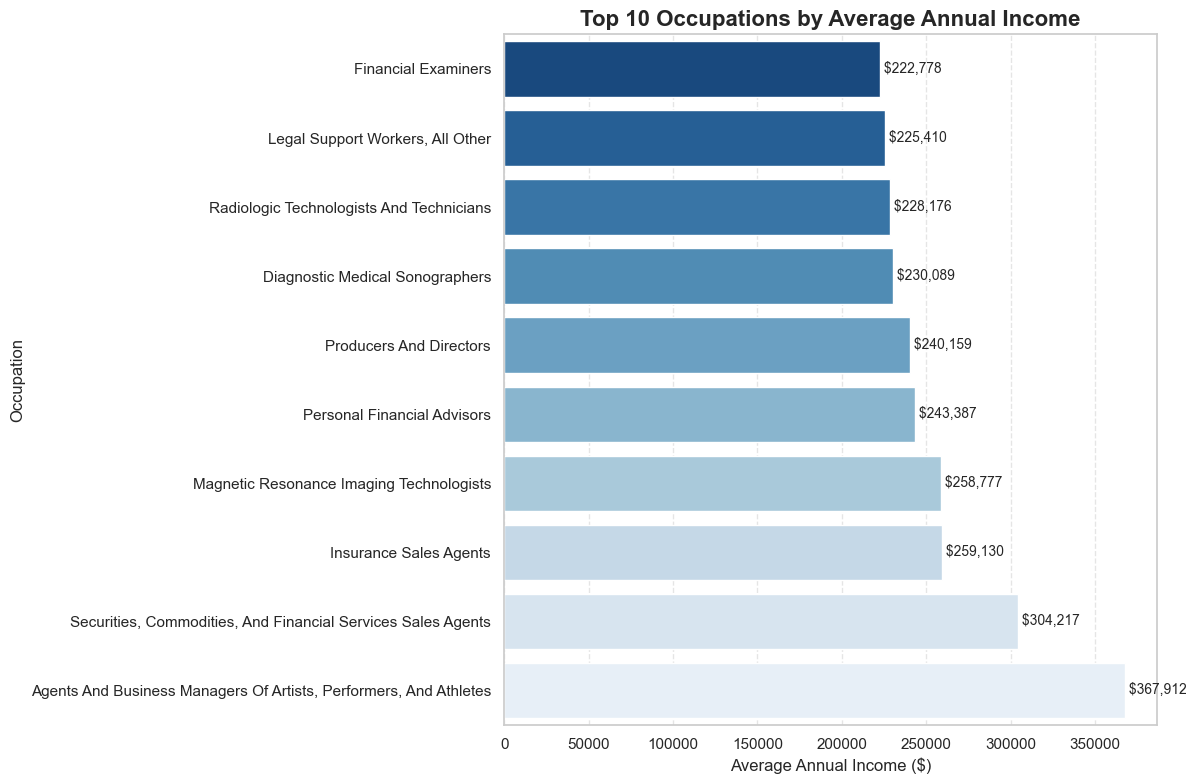

Plot saved to: Images\Top_Occupations_Avg_Income.png


In [57]:
# Top 10 occupations by average annual income
plt.figure(figsize=(12, 8))
top_occupations = (
    df.groupby('Occupation')['Annual Income']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .iloc[::-1]  # reverse for horizontal bar ascending order
)

ax = sns.barplot(x=top_occupations.values, y=top_occupations.index, palette='Blues_r')
ax.set_title('Top 10 Occupations by Average Annual Income', fontsize=16, weight='bold')
ax.set_xlabel('Average Annual Income ($)')
ax.set_ylabel('Occupation')
for i, v in enumerate(top_occupations.values):
    ax.text(v, i, f" ${v:,.0f}", va='center', ha='left', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Top_Occupations_Avg_Income.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: The chart highlights which occupations command the highest average incomes among high-paid roles. The gap between the top few suggests concentrated earning power in specialized fields.

Question 2: What is the average annual income by education level?

Visualization

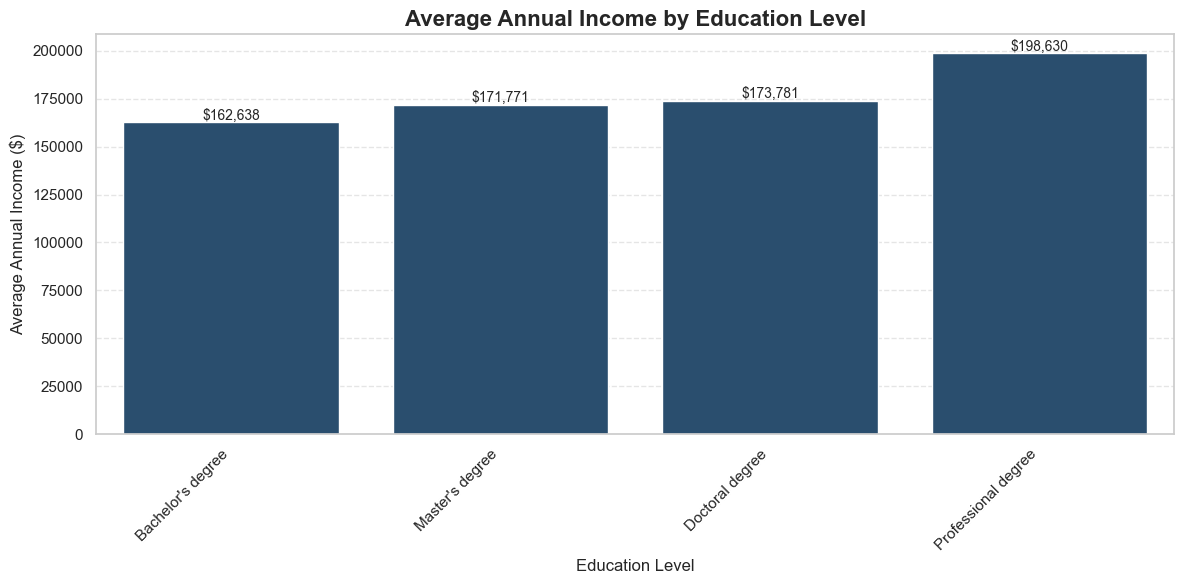

Plot saved to: Images\Average_Income_by_Education_Level.png


In [58]:
# Average annual income by education level
edu_income = (
    df.groupby('Education Level')['Annual Income']
      .mean()
      .sort_values()
      .reset_index()
 )

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Education Level', y='Annual Income', data=edu_income, color=PALETTE['money_color'])
ax.set_title('Average Annual Income by Education Level', fontsize=16, weight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Annual Income ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    h = p.get_height()
    x = p.get_x() + p.get_width() / 2
    ax.text(x, h, f"${h:,.0f}", va='bottom', ha='center', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Average_Income_by_Education_Level.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: Higher education levels are associated with higher average incomes among high-paid workers. The step-up between adjacent levels indicates incremental returns to education.

Question 3: How does gender distribution vary across high-paying occupations?


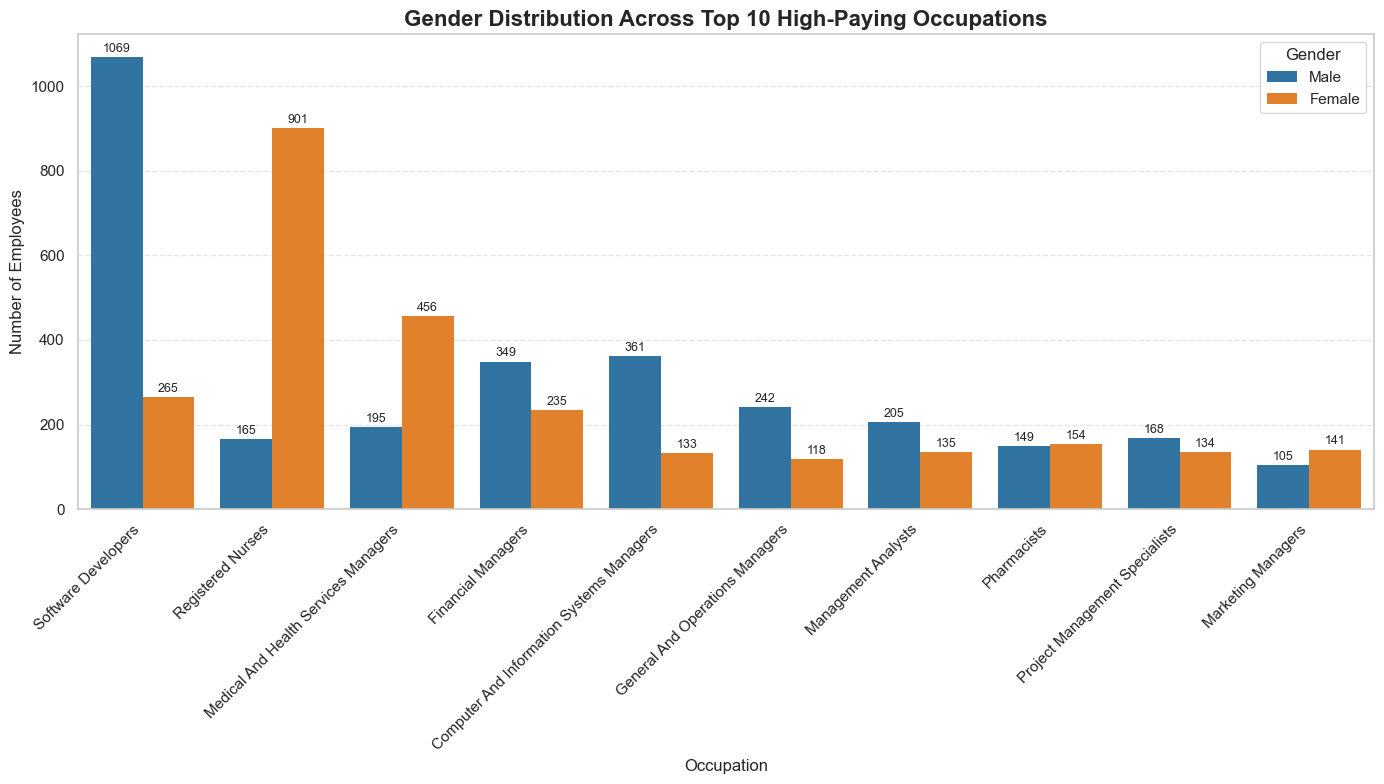

Plot saved to: Images\Gender_Distribution_Occupations.png


In [59]:
# Gender distribution across the most common high-paying occupations
plt.figure(figsize=(14, 8))
order = df['Occupation'].value_counts().index[:10]
ax = sns.countplot(
    x='Occupation',
    hue='Gender',
    data=df[df['Occupation'].isin(order)],
    order=order,
    palette=PALETTE['gender']
 )

for container in plt.gca().containers:
    plt.setp(container, linewidth=0)
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Gender Distribution Across Top 10 High-Paying Occupations', fontsize=16, weight='bold')
ax.set_xlabel('Occupation')
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Gender')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Gender_Distribution_Occupations.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: The gender split varies by occupation. Some roles are more balanced, while others skew male or female, hinting at occupational segregation within high-paid jobs.

Question 4: How is the gender distribution in high-paying jobs ($100K+) across different states?



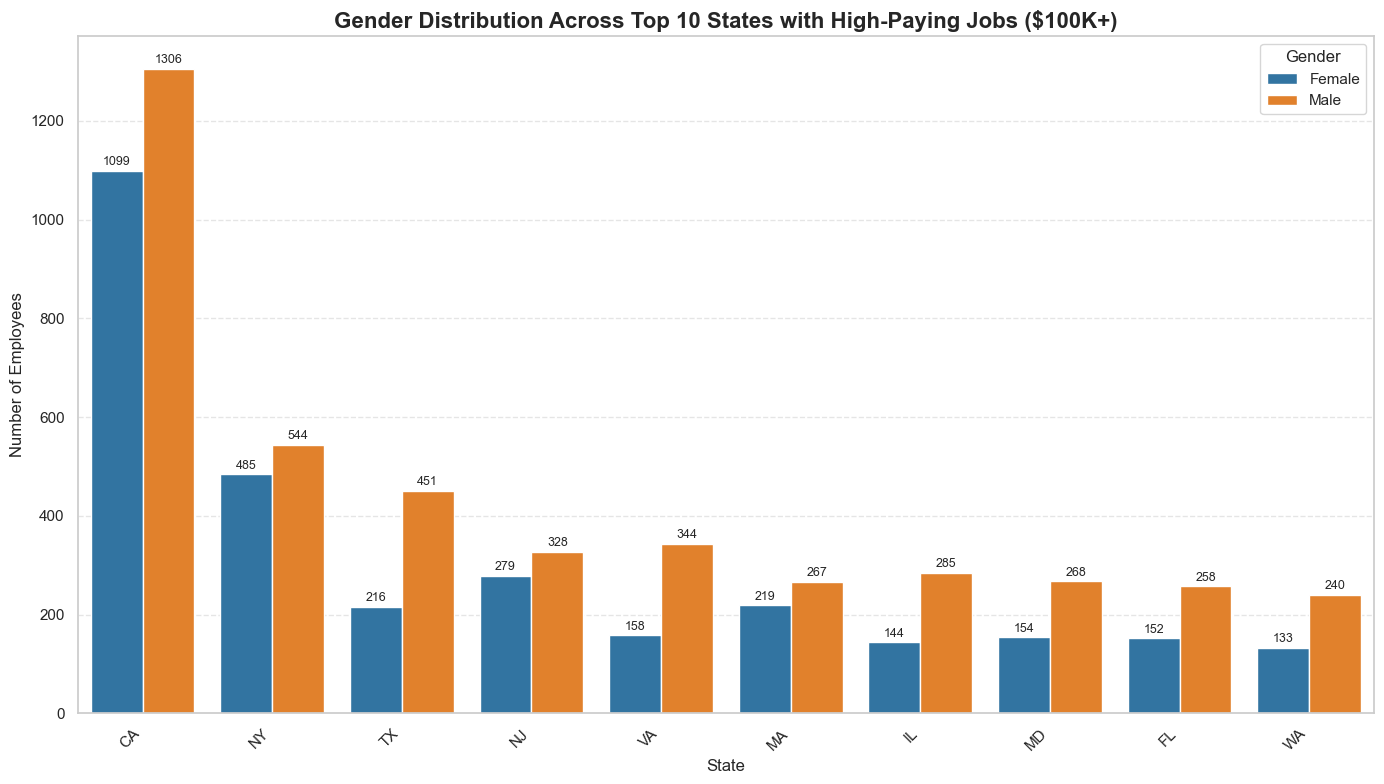

Plot saved to: Images\Gender_Distribution_States.png


In [60]:
# Gender distribution in high-paying jobs across top states
state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
top_states = df[state_col].value_counts().index[:10]
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    x=state_col,
    hue='Gender',
    data=df[df[state_col].isin(top_states)],
    order=top_states,
    palette=PALETTE['gender']
 )
for container in plt.gca().containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}', ha='center', va='bottom', fontsize=9)
ax.set_title('Gender Distribution Across Top 10 States with High-Paying Jobs ($100K+)', fontsize=16, weight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Gender')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Gender_Distribution_States.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: Large labor markets dominate high-paying roles. Gender balance differs by state, suggesting local industry mix and labor supply effects.

"What are the most common education levels and their relationship with gender distribution in high-paying jobs ($100K+) across states?"

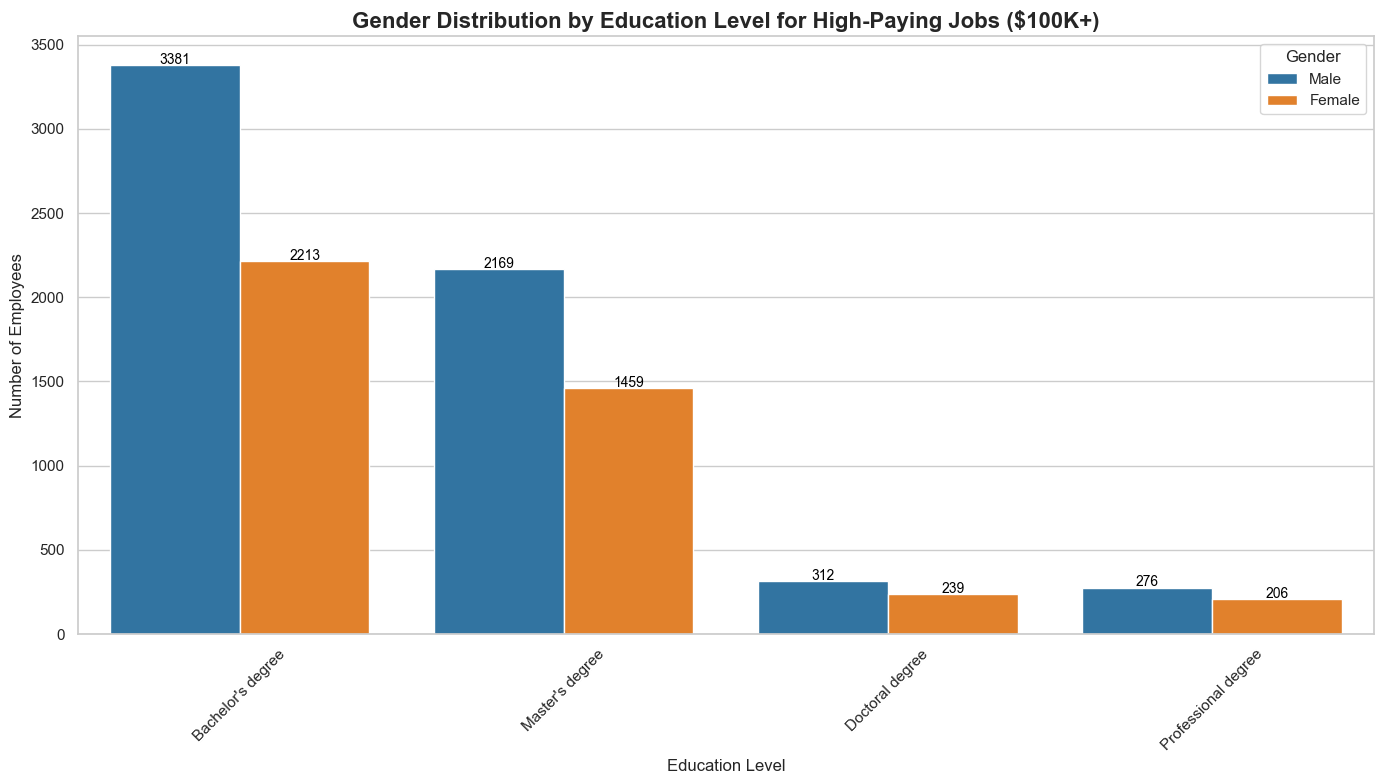

Plot saved to: Images\Gender_Education_Distribution.png


In [61]:
# Set the figure size
plt.figure(figsize=(14, 8))

# Filter data for high-paying jobs only
high_paying_df = df[df['Annual Income'] >= 100000]

# Create a countplot to show the gender distribution by education level
sns.countplot(
    x='Education Level',
    hue='Gender',
    data=high_paying_df,
    order=high_paying_df['Education Level'].value_counts().index[:10],  # Filter the top 10 most common education levels
    palette=PALETTE['gender']
)

 # Annotate counts on top of each bar
for p in plt.gca().containers:
    for bar in p:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center annotation
            height + 30,  # Slight offset above the bar
            f'{int(height)}',
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

# Additional styling for better visualization
plt.title('Gender Distribution by Education Level for High-Paying Jobs ($100K+)', fontsize=16, weight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis for better clarity
plt.legend(title='Gender')
plt.tight_layout()

# Save the plot
plot_path = 'Images/Gender_Education_Distribution.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: Gender mix differs by education level within $100K+ roles, suggesting different educational pipelines into high-paying jobs.

What is the relationship between age and annual income for high-paying jobs?

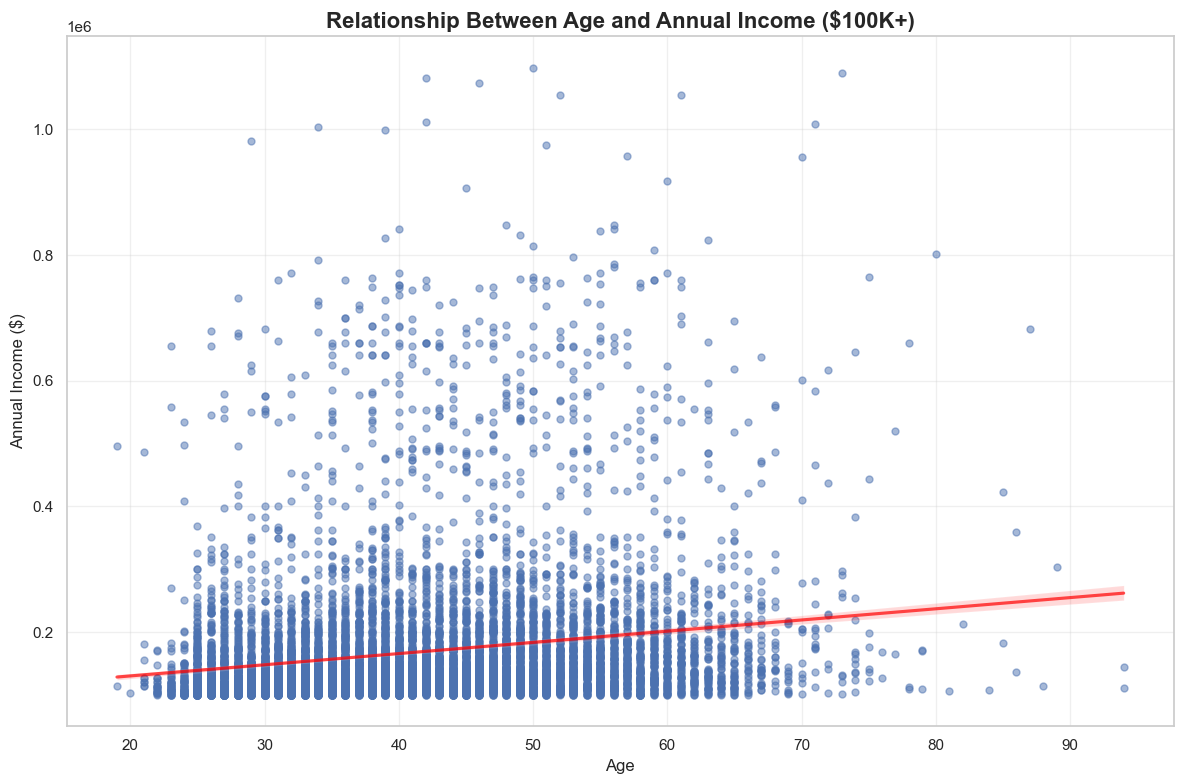

Plot saved to: Images\Age_Annual_Income.png


In [62]:
# Relationship between age and annual income
if 'Age' in df.columns:
    plt.figure(figsize=(12, 8))
    ax = sns.regplot(
        x='Age',
        y='Annual Income',
        data=df,
        scatter_kws={'alpha': 0.5, 's': 25},
        line_kws={'color': 'red', 'alpha': 0.7}
    )
    ax.set_title('Relationship Between Age and Annual Income ($100K+)', fontsize=16, weight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Annual Income ($)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = 'Images/Age_Annual_Income.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Age' not found.")

Interpretation: Income tends to rise with age early in careers and plateaus later. The visible scatter suggests other factors (role, location) also matter.

 Question 5: What are the most common occupations among high-paid individuals?

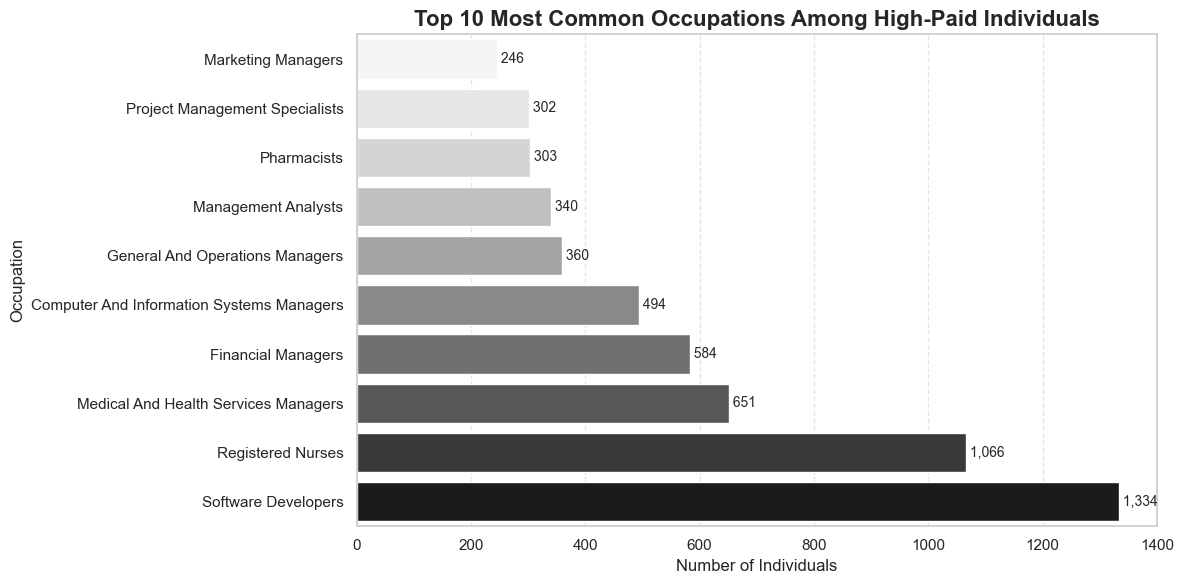

Plot saved to: Images\Top_Occupations_High_Paid.png


In [63]:
# Most common occupations among high-paid individuals
top_counts = df['Occupation'].value_counts().head(10).iloc[::-1]
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_counts.values, y=top_counts.index, palette=PALETTE['count_seq'])
ax.set_title('Top 10 Most Common Occupations Among High-Paid Individuals', fontsize=16, weight='bold')
ax.set_xlabel('Number of Individuals')
ax.set_ylabel('Occupation')
for i, v in enumerate(top_counts.values):
    ax.text(v, i, f' {v:,}', va='center', ha='left', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Top_Occupations_High_Paid.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: These roles are the most prevalent among $100K+ earners, pointing to where high-paying opportunities are concentrated by headcount (not necessarily pay level).

Question 6: What is the distribution of high-paid individuals across different states?

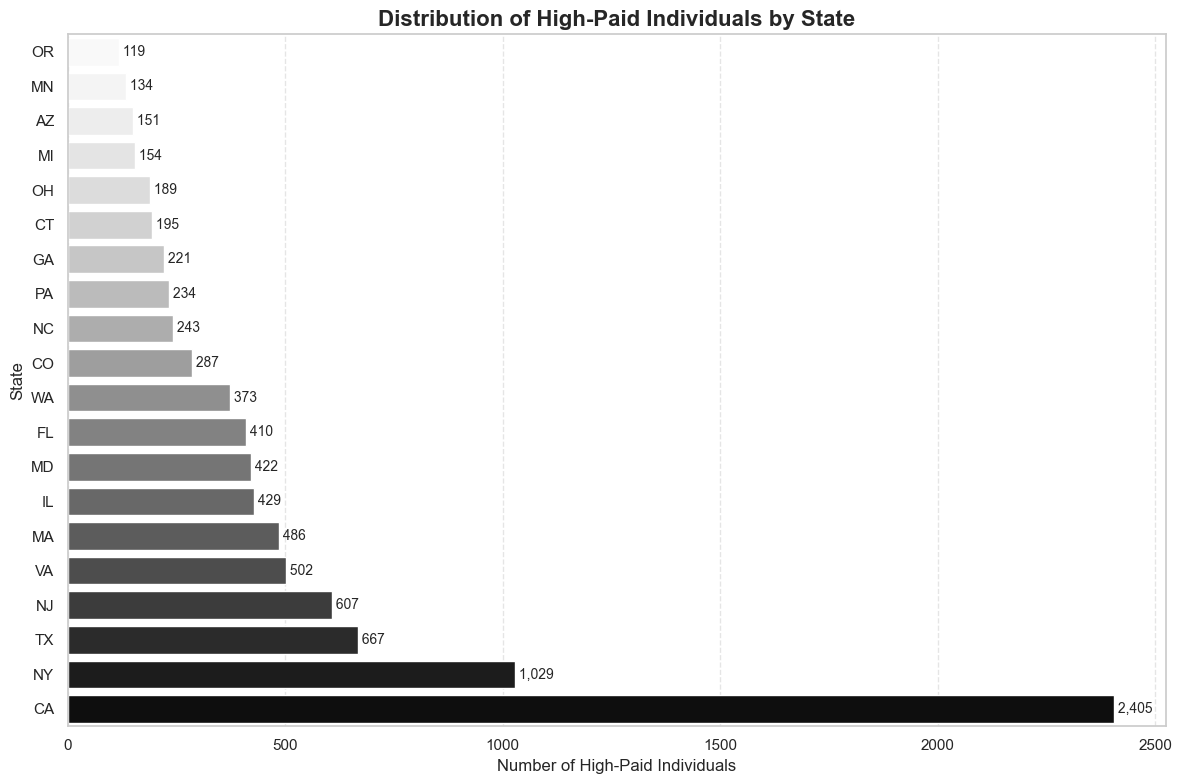

Plot saved to: Images\High_Paid_Individuals_by_State.png


In [64]:
# Distribution of high-paid individuals across states
state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
state_distribution = (
    df.groupby(state_col)['Annual Income'].count().sort_values(ascending=True).tail(20)
)
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=state_distribution.values, y=state_distribution.index, palette=PALETTE['count_seq'])
ax.set_title('Distribution of High-Paid Individuals by State', fontsize=16, weight='bold')
ax.set_xlabel('Number of High-Paid Individuals')
ax.set_ylabel('State')
for i, v in enumerate(state_distribution.values):
    ax.text(v, i, f' {v:,}', va='center', ha='left', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/High_Paid_Individuals_by_State.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: High-paying headcount clusters in large economies and tech/finance hubs. Smaller states appear less often due to market size rather than pay rates.

 Question 7: How does the average salary vary across different occupations?


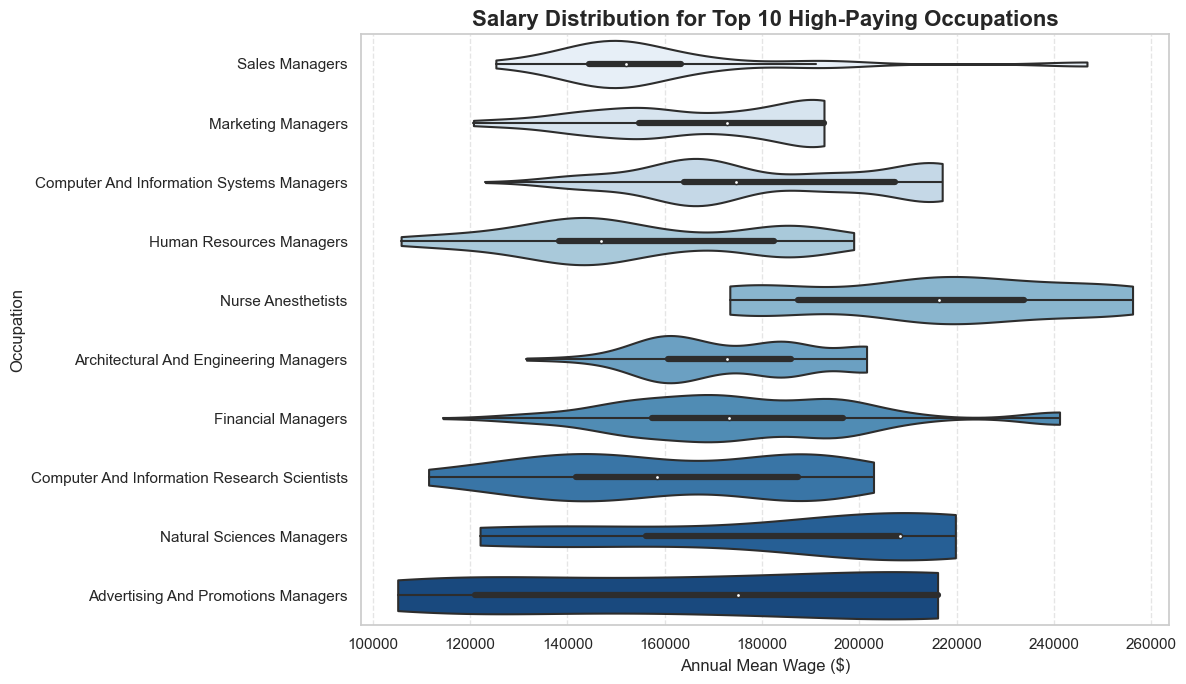

Plot saved to: Images\Top_10_Salary_Distribution.png


In [65]:
# Salary distribution for top 10 high-paying occupations (by Annual Mean Wage)
if 'Annual Mean Wage' in df.columns:
    top_by_wage = (
        df.groupby('Occupation')['Annual Mean Wage'].mean().nlargest(10).index
)
    plt.figure(figsize=(12, 7))
    ax = sns.violinplot(
        data=df[df['Occupation'].isin(top_by_wage)],
        x='Annual Mean Wage',
        y='Occupation',
        palette='Blues',
        scale='width',
        cut=0,
    )
    ax.set_title('Salary Distribution for Top 10 High-Paying Occupations', fontsize=16, weight='bold')
    ax.set_xlabel('Annual Mean Wage ($)')
    ax.set_ylabel('Occupation')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_path = 'Images/Top_10_Salary_Distribution.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Annual Mean Wage' not found.")

Interpretation: Distributions vary widely across top occupations; some show tight clustering (consistent pay), while others have long tails indicating broader pay dispersion.

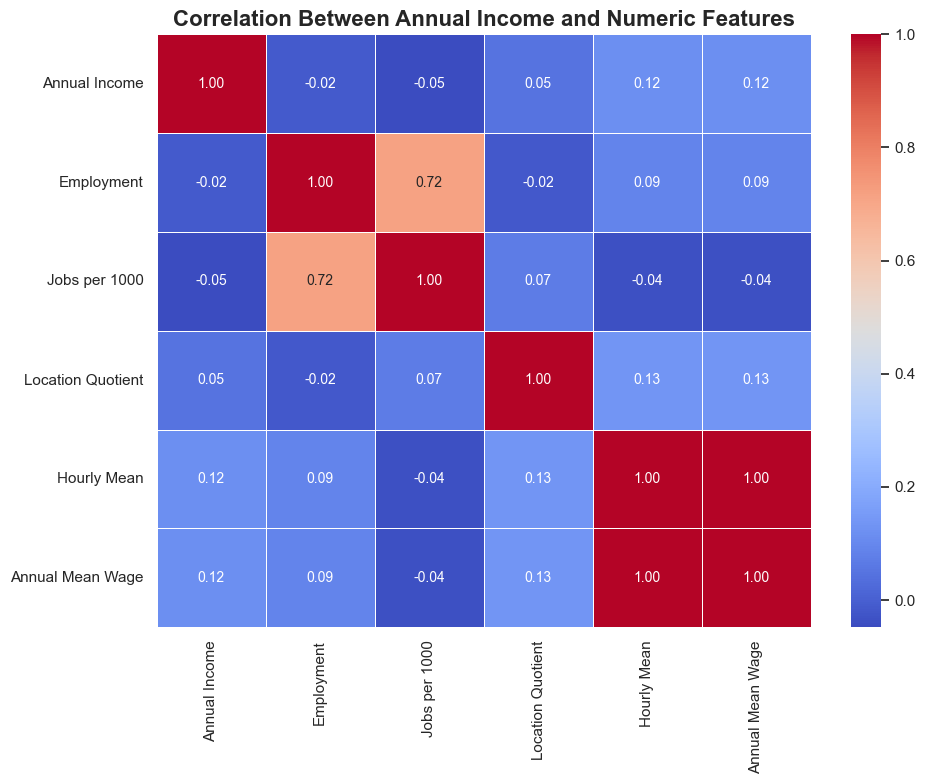

Plot saved to: Images\Correlation_Annual_Income.png


In [66]:
# Correlation among numeric features
num_candidates = [
    'Annual Income', 'Employment', 'Jobs per 1000',
    'Location Quotient', 'Hourly Mean', 'Annual Mean Wage'
 ]
num_cols = [c for c in num_candidates if c in df.columns]
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
    ax.set_title('Correlation Between Annual Income and Numeric Features', fontsize=16, weight='bold')
    plt.tight_layout()
    plot_path = 'Images/Correlation_Annual_Income.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print(f'Skipped: not enough numeric columns found among: {num_cols}')

Interpretation: Employment and jobs-per-1000 move together, wages co-move as expected, while annual income shows weak links—implying unobserved drivers beyond these metrics.

The correlation analysis shows the following straightforward insights:

Annual Income has weak or negligible correlations with other features, suggesting factors beyond this dataset might drive income differences.
Employment and Jobs per 1000 are strongly correlated, indicating that areas with more employment opportunities naturally have more jobs available per capita.
Location Quotient slightly correlates with Hourly Mean and Annual Mean Wage, implying that regions with higher job concentrations might offer better wages.
Hourly Mean and Annual Mean Wage are perfectly correlated, as expected, since annual wages are calculated from hourly rates.
This suggests income is weakly influenced by job concentration or employment but may depend on other variables.

Question 8: How does the average annual income vary across states?

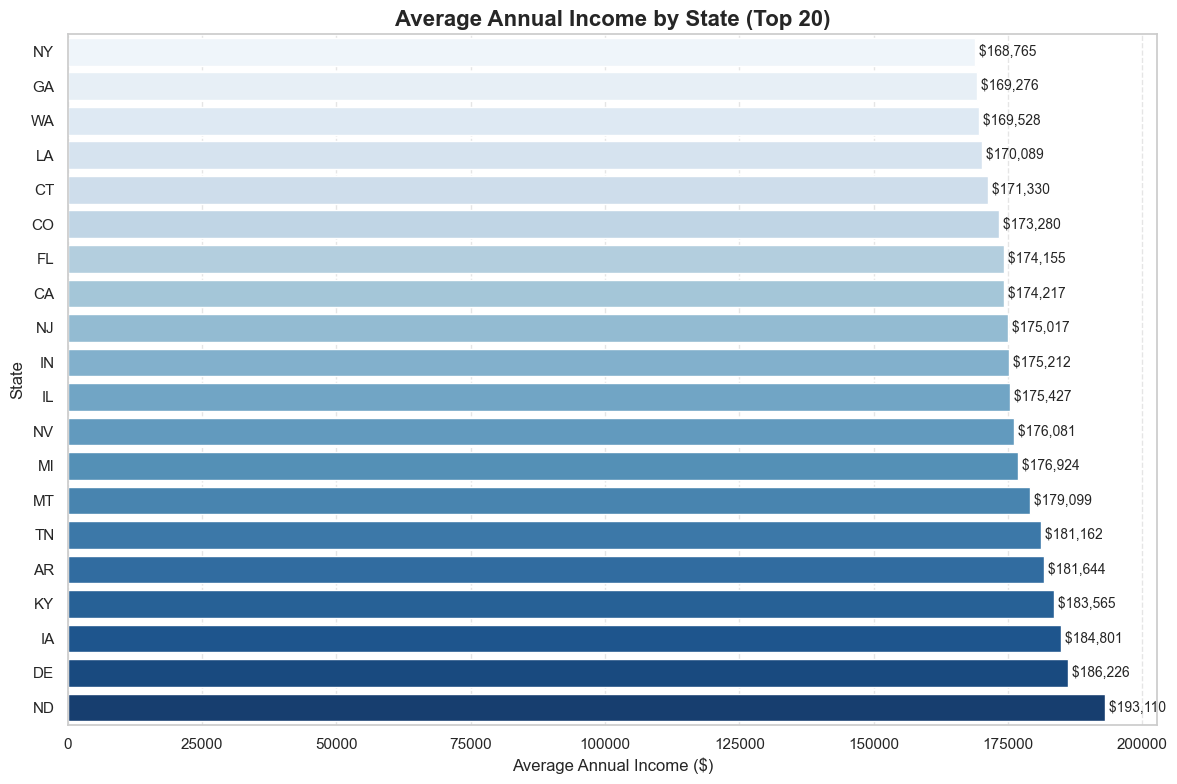

Plot saved to: Images\Average_Highest_Income_state_Viz.png


In [67]:
# Average annual income by state (Top 20)
state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
state_avg_income = (
    df.groupby(state_col)['Annual Income'].mean().sort_values().tail(20)
 )
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=state_avg_income.values, y=state_avg_income.index, palette=PALETTE['money_seq'])
ax.set_title('Average Annual Income by State (Top 20)', fontsize=16, weight='bold')
ax.set_xlabel('Average Annual Income ($)')
ax.set_ylabel('State')
for i, v in enumerate(state_avg_income.values):
    ax.text(v, i, f' ${v:,.0f}', va='center', ha='left', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Average_Highest_Income_state_Viz.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: States with strong tech/finance presence and high cost-of-living tend to show higher average incomes among $100K+ roles. Differences likely reflect industry mix and local wage levels, not just headcount.

Question 9: Which states have the highest concentration of high-paying jobs (Location Quotient)?

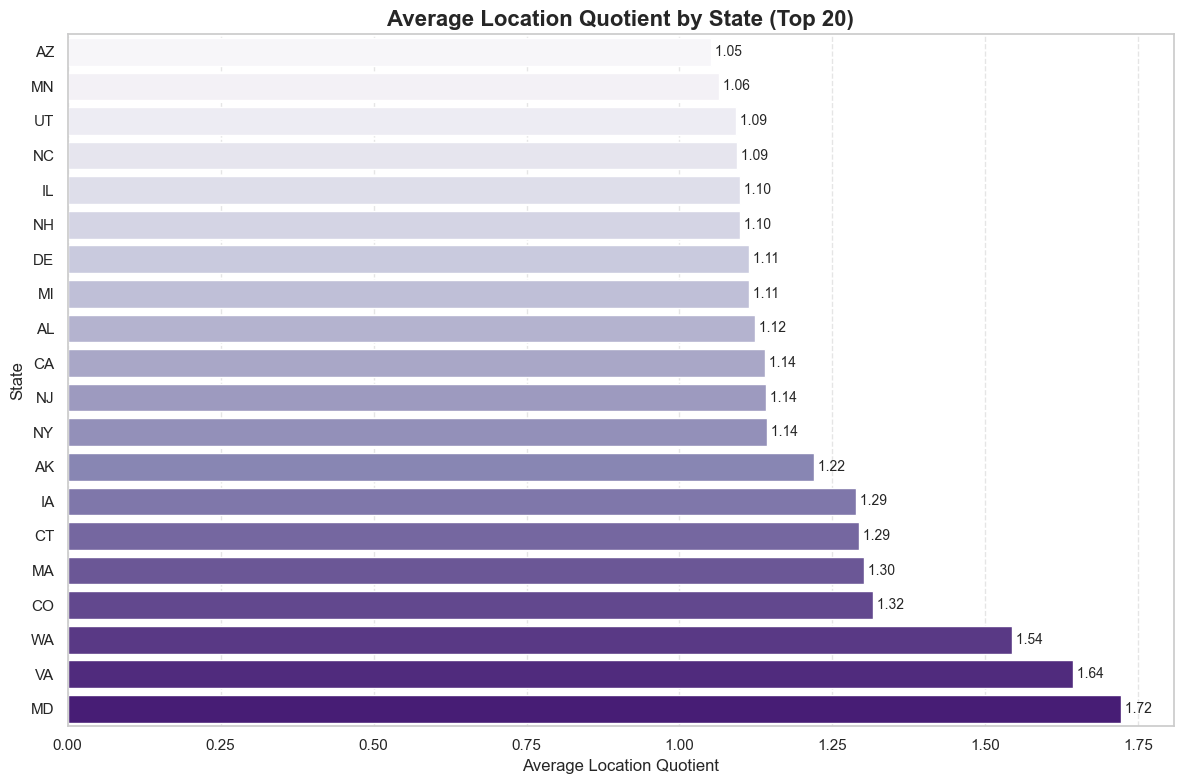

Plot saved to: Images\High_Paying_Jobs_LQ_Distribution_Viz.png


In [68]:
# Location Quotient by state (Top 20 average)
if 'Location Quotient' in df.columns:
    state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
    lq_by_state = (
        df.groupby(state_col)['Location Quotient'].mean().sort_values().tail(20)
    )
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=lq_by_state.values, y=lq_by_state.index, palette=PALETTE['lq_seq'])
    ax.set_title('Average Location Quotient by State (Top 20)', fontsize=16, weight='bold')
    ax.set_xlabel('Average Location Quotient')
    ax.set_ylabel('State')
    for i, v in enumerate(lq_by_state.values):
        ax.text(v, i, f' {v:,.2f}', va='center', ha='left', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_path = 'Images/High_Paying_Jobs_LQ_Distribution_Viz.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Location Quotient' not found.")

Interpretation: Higher LQ indicates states where high-paying occupations are more concentrated relative to the national average, often reflecting specialized industry clusters.

Question 10: What is the dominant education level among $100K+ workers in each state?

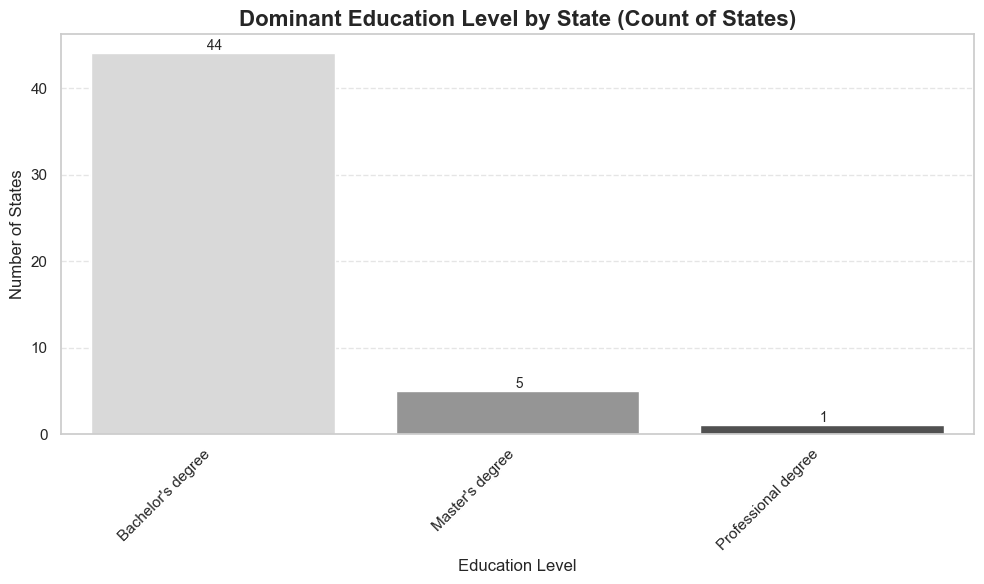

Plot saved to: Images\Dominant_education_by_state_Viz.png


In [69]:
# Dominant education level by state (mode among $100K+ workers)
if 'Education Level' in df.columns:
    state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
    high_df = df[df['Annual Income'] >= 100000]
    dominant = (
        high_df.groupby(state_col)['Education Level']
        .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
        .dropna()
        .rename('Dominant Education')
    )
    dom_counts = dominant.value_counts()
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=dom_counts.index, y=dom_counts.values, palette=PALETTE['count_seq'])
    ax.set_title('Dominant Education Level by State (Count of States)', fontsize=16, weight='bold')
    ax.set_xlabel('Education Level')
    ax.set_ylabel('Number of States')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    for i, v in enumerate(dom_counts.values):
        ax.text(i, v, f' {v:,}', va='bottom', ha='center', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_path = 'Images/Dominant_education_by_state_Viz.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Education Level' not found.")

Interpretation: Most states’ $100K+ earners are concentrated in higher education levels, though a few states show strong representation from professional or specialized degrees.

Question 11: What is the education–income premium by state?

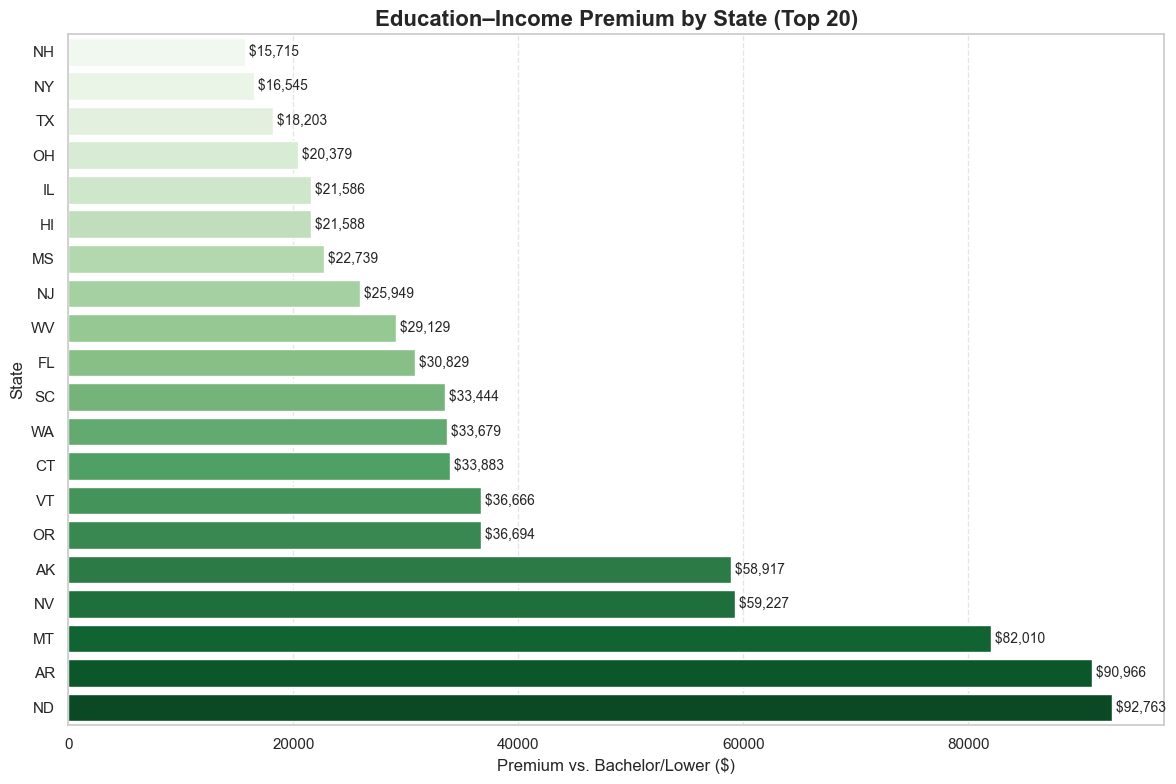

Plot saved to: Images\Education_Income_Premiums_by_State_Viz.png


In [70]:
# Education–Income premium by state: (Advanced Degree avg) - (Bachelor or less avg) among $100K+
if 'Education Level' in df.columns:
    state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
    high_df = df[df['Annual Income'] >= 100000].copy()
    # Define buckets
    def edu_bucket(x):
        x = str(x).lower()
        if 'phd' in x or 'doctor' in x or 'professional' in x or 'master' in x:
            return 'Advanced'
        elif 'bachelor' in x:
            return 'Bachelor'
        else:
            return 'Lower'
    high_df['EduBucket'] = high_df['Education Level'].apply(edu_bucket)
    # Compute averages by state and bucket
    avg_by = high_df.groupby([state_col, 'EduBucket'])['Annual Income'].mean().unstack()
    # Ensure columns exist
    for col in ['Advanced','Bachelor','Lower']:
        if col not in avg_by.columns: avg_by[col] = np.nan
    # Premium: Advanced minus max(Bachelor, Lower)
    premium = (avg_by['Advanced'] - avg_by[['Bachelor','Lower']].max(axis=1)).dropna().sort_values().tail(20)
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=premium.values, y=premium.index, palette=PALETTE['premium_seq'])
    ax.set_title('Education–Income Premium by State (Top 20)', fontsize=16, weight='bold')
    ax.set_xlabel('Premium vs. Bachelor/Lower ($)')
    ax.set_ylabel('State')
    for i, v in enumerate(premium.values):
        ax.text(v, i, f' ${v:,.0f}', va='center', ha='left', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_path = 'Images/Education_Income_Premiums_by_State_Viz.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Education Level' not found.")

Interpretation: The premium for advanced degrees varies by state—larger in markets where specialized credentials are rewarded (e.g., finance, tech, healthcare hubs).

Question 12: Does market size relate to the education–income premium?

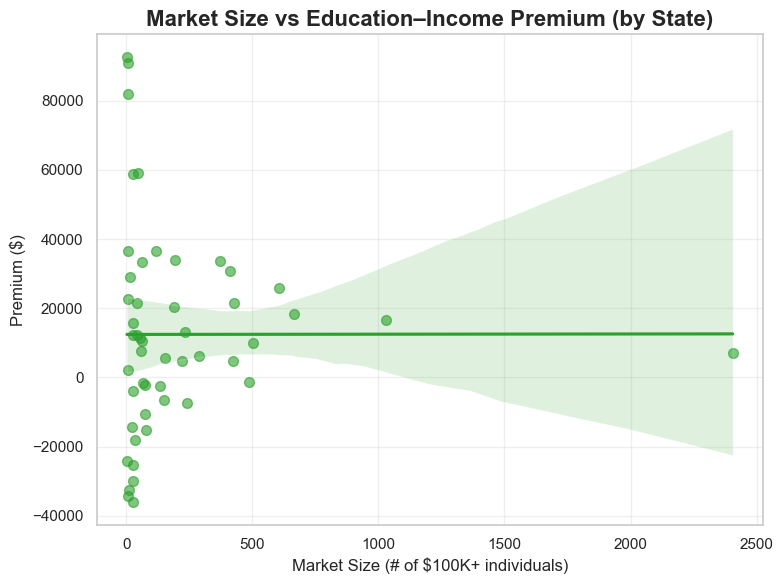

Plot saved to: Images\Market_Size_Income_Premium_Analysis_Viz.png


In [71]:
# Market size (count of $100K+ individuals) vs education premium (from previous cell)
if 'Education Level' in df.columns:
    state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
    high_df = df[df['Annual Income'] >= 100000].copy()
    # Recompute premium table to have full vector for merge
    def edu_bucket(x):
        x = str(x).lower()
        if 'phd' in x or 'doctor' in x or 'professional' in x or 'master' in x:
            return 'Advanced'
        elif 'bachelor' in x:
            return 'Bachelor'
        else:
            return 'Lower'
    high_df['EduBucket'] = high_df['Education Level'].apply(edu_bucket)
    avg_by = high_df.groupby([state_col, 'EduBucket'])['Annual Income'].mean().unstack()
    for col in ['Advanced','Bachelor','Lower']:
        if col not in avg_by.columns: avg_by[col] = np.nan
    premium_series = (avg_by['Advanced'] - avg_by[['Bachelor','Lower']].max(axis=1)).rename('Premium')
    market_size = high_df.groupby(state_col).size().rename('MarketSize')
    plot_df = pd.concat([premium_series, market_size], axis=1).dropna()
    plt.figure(figsize=(8, 6))
    ax = sns.regplot(data=plot_df, x='MarketSize', y='Premium',
                     scatter_kws={'alpha':0.6, 's':50, 'color': PALETTE['premium_point']},
                     line_kws={'color': PALETTE['premium_point']})
    ax.set_title('Market Size vs Education–Income Premium (by State)', fontsize=16, weight='bold')
    ax.set_xlabel('Market Size (# of $100K+ individuals)')
    ax.set_ylabel('Premium ($)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = 'Images/Market_Size_Income_Premium_Analysis_Viz.png'
    saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)
else:
    print("Skipped: 'Education Level' not found.")

Interpretation: Larger markets often exhibit higher premiums, but the relationship isn’t deterministic—suggesting local industry composition matters more than sheer size.

Question 13: Are there regional patterns in high-paying jobs across the US?

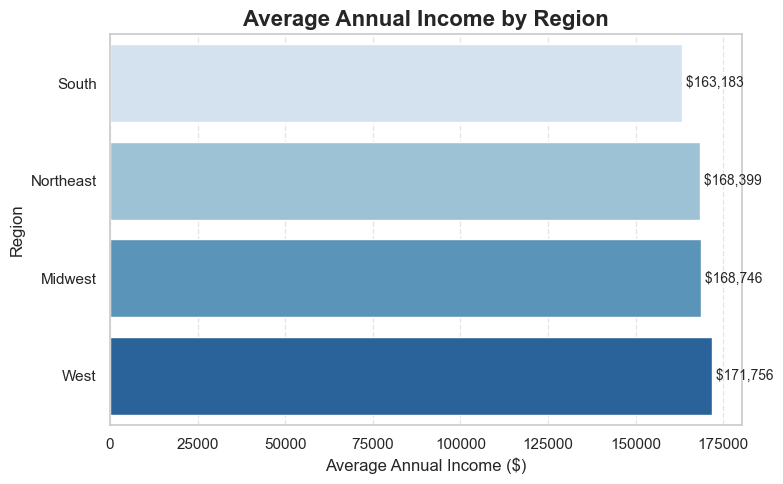

Plot saved to: Images\Regional_Patterns_Analysis_Viz.png


In [72]:
# Regional patterns: map states to US Census regions and summarize
state_col = 'State Abbreviation' if 'State Abbreviation' in df.columns else 'State'
# Basic mapping for 50 states + DC
REGION_MAP = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest','IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South','WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}
df_region = df.copy()
if state_col == 'State Abbreviation':
    df_region['Region'] = df_region[state_col].map(REGION_MAP)
else:
    # Try to infer from state names if provided (optional, minimal)
    NAME_TO_ABBR = {
        'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE','District of Columbia':'DC','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
    }
    df_region['Region'] = df_region[state_col].map(NAME_TO_ABBR).map(REGION_MAP)
region_summary = df_region.dropna(subset=['Region']).copy()
# Average income and market share by region
avg_income_region = region_summary.groupby('Region')['Annual Income'].mean().sort_values()
market_share = (region_summary.groupby('Region').size() / len(region_summary)).sort_values()
# Plot average income by region
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=avg_income_region.values, y=avg_income_region.index, palette=PALETTE['money_seq'])
ax.set_title('Average Annual Income by Region', fontsize=16, weight='bold')
ax.set_xlabel('Average Annual Income ($)')
ax.set_ylabel('Region')
for i, v in enumerate(avg_income_region.values):
    ax.text(v, i, f' ${v:,.0f}', va='center', ha='left', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = 'Images/Regional_Patterns_Analysis_Viz.png'
saved_path = save_show_close(plot_path, bbox_inches='tight', dpi=300)

Interpretation: Regions with dense tech/finance ecosystems (West, Northeast) show higher average incomes, while market share reflects population size and economic concentration.